In [13]:
import pandas as pd
import seaborn as sns
from rapidfuzz import process, fuzz

# Process EPC non-domestic

## Column filtering

In [14]:
sample_nd = pd.read_csv("data/epc-nondomestic.csv", nrows=1000)
sample_nd.head()

,certificate_number,address1,address2,address3,posttown,postcode,address,constituency,constituency_label,local_authority,...,building_emissions,aircon_present,aircon_kw_rating,estimated_aircon_kw_rating,ac_inspection_commissioned,building_environment,report_type,primary_energy_value,uprn,uprn_source
0,0000-7404-5801-3694-5935,Rowan House,Hill End Lane,NaN,ST ALBANS,AL4 0RA,"Rowan House, Hill End Lane",E14001507,St Albans,E07000240,...,35.76,No,NaN,NaN,4,Heating and Natural Ventilation,3,221.99,1.000107e+10,Energy Assessor
1,0000-9278-0696-8196-1282,42 George Street,Great Harwood,NaN,BLACKBURN,BB6 7JF,"42 George Street, Great Harwood",E14001299,Hyndburn,E07000120,...,159.05,No,NaN,NaN,4,Heating and Natural Ventilation,3,884.97,1.000104e+11,Energy Assessor
2,0001-2150-4009-1081-1260,251-253 London Road East,Batheaston,NaN,Bath,BA1 7RL,"251-253 London Road East, Batheaston",E14001080,Bath,E06000022,...,69.44,No,NaN,NaN,4,Heating and Natural Ventilation,3,401.12,1.001212e+11,Energy Assessor
3,0001-2823-0043-0321-7174,BLACK HORSE,COVENTRY ROAD,MARTON,CV23 9RH,CV23 9RH,"BLACK HORSE, COVENTRY ROAD, MARTON",E14001309,Kenilworth and Southam,E07000220,...,82.62,No,NaN,NaN,4,Heating and Natural Ventilation,3,614.19,1.001052e+10,Address Matched
4,0001-6857-5728-6832-3157,143 WATER STREET,RADCLIFFE,NaN,RADCLIFFE,M26 3BJ,"143 WATER STREET, RADCLIFFE",E14001145,Bury South,E08000002,...,33.44,No,NaN,NaN,4,Heating and Natural Ventilation,3,193.75,1.000124e+11,Energy Assessor


In [15]:
cols_nd = ["asset_rating_band", 
           "property_type", 
           "lodgement_date",
           "main_heating_fuel",
           "other_fuel_desc",
           "special_energy_uses",
           "renewable_sources",
           "floor_area",
           "asset_rating",
           "inspection_date",
           "standard_emissions",
           "target_emissions",
           "typical_emissions",
           "building_emissions",
           "aircon_present",
           "lodgement_datetime",
           "primary_energy_value",
           "building_level",
           "ac_inspection_commissioned",
           "building_environment",
           "uprn"
           ]
df_nd = pd.read_csv("data/epc-nondomestic.csv", usecols=cols_nd)
df_nd.head()

,asset_rating,asset_rating_band,property_type,inspection_date,lodgement_date,lodgement_datetime,building_level,main_heating_fuel,other_fuel_desc,special_energy_uses,...,floor_area,standard_emissions,target_emissions,typical_emissions,building_emissions,aircon_present,ac_inspection_commissioned,building_environment,primary_energy_value,uprn
0,77,D,Offices and Workshop Businesses,2023-09-19,2023-09-25,2023-09-25 14:34:24,3,Natural Gas,NaN,NaN,...,45,23.15,9.44,37.84,35.76,No,4,Heating and Natural Ventilation,221.99,1.000107e+10
1,58,C,Hotels,2022-09-12,2022-09-16,2022-09-20 19:17:12,3,Natural Gas,NaN,NaN,...,133,136.78,88.90,356.50,159.05,No,4,Heating and Natural Ventilation,884.97,1.000104e+11
2,81,D,B1 Offices and Workshop businesses,2022-03-05,2022-03-05,2022-03-05 07:43:45,3,Natural Gas,NaN,NaN,...,369,42.82,18.01,52.78,69.44,No,4,Heating and Natural Ventilation,401.12,1.001212e+11
3,72,C,Restaurants and Cafes/Drinking Establishments/...,2023-12-12,2024-01-31,2024-01-31 16:42:08,3,Natural Gas,NaN,NaN,...,355,57.27,27.34,109.63,82.62,No,4,Heating and Natural Ventilation,614.19,1.001052e+10
4,66,C,A1/A2 Retail and Financial/Professional services,2020-10-05,2020-10-07,2020-10-07 19:08:45,3,Natural Gas,NaN,NaN,...,579,25.14,13.81,40.46,33.44,No,4,Heating and Natural Ventilation,193.75,1.000124e+11


In [16]:
df_nd.columns = df_nd.columns.str.replace("_", " ")
df_nd.columns = df_nd.columns.str.title()
df_nd.columns = df_nd.columns.str.replace(" ", "")
df_nd.head()

,AssetRating,AssetRatingBand,PropertyType,InspectionDate,LodgementDate,LodgementDatetime,BuildingLevel,MainHeatingFuel,OtherFuelDesc,SpecialEnergyUses,...,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AirconPresent,AcInspectionCommissioned,BuildingEnvironment,PrimaryEnergyValue,Uprn
0,77,D,Offices and Workshop Businesses,2023-09-19,2023-09-25,2023-09-25 14:34:24,3,Natural Gas,NaN,NaN,...,45,23.15,9.44,37.84,35.76,No,4,Heating and Natural Ventilation,221.99,1.000107e+10
1,58,C,Hotels,2022-09-12,2022-09-16,2022-09-20 19:17:12,3,Natural Gas,NaN,NaN,...,133,136.78,88.90,356.50,159.05,No,4,Heating and Natural Ventilation,884.97,1.000104e+11
2,81,D,B1 Offices and Workshop businesses,2022-03-05,2022-03-05,2022-03-05 07:43:45,3,Natural Gas,NaN,NaN,...,369,42.82,18.01,52.78,69.44,No,4,Heating and Natural Ventilation,401.12,1.001212e+11
3,72,C,Restaurants and Cafes/Drinking Establishments/...,2023-12-12,2024-01-31,2024-01-31 16:42:08,3,Natural Gas,NaN,NaN,...,355,57.27,27.34,109.63,82.62,No,4,Heating and Natural Ventilation,614.19,1.001052e+10
4,66,C,A1/A2 Retail and Financial/Professional services,2020-10-05,2020-10-07,2020-10-07 19:08:45,3,Natural Gas,NaN,NaN,...,579,25.14,13.81,40.46,33.44,No,4,Heating and Natural Ventilation,193.75,1.000124e+11


## String matching for PropertyType

In [17]:
df_nd['PropertyType'].nunique()

44

In [18]:
property_type = df_nd['PropertyType'].unique()
print(property_type)

<StringArray>
[                                             'Offices and Workshop Businesses',
                                                                       'Hotels',
                                           'B1 Offices and Workshop businesses',
                      'Restaurants and Cafes/Drinking Establishments/Takeaways',
                             'A1/A2 Retail and Financial/Professional services',
 'A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways',
                                   'Retail/Financial and Professional Services',
                                                                    'C1 Hotels',
               'D1 Non-residential Institutions - Primary Health Care Building',
                             'General Industrial and Special Industrial Groups',
                    'B2 to B7 General Industrial and Special Industrial Groups',
                       'D1 Non-residential Institutions - Community/Day Centre',
              

In [19]:
fuzz.ratio("Restaurants and Cafes/Drinking Establishments/Takeaways", "A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways")
fuzz.token_set_ratio("Restaurants and Cafes/Drinking Establishments/Takeaways", "A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways")

70.86614173228347

In [20]:
fuzz.token_set_ratio("Storage or Distribution", "B8 Storage or Distribution")

100.0

In [21]:
for type in property_type:
        #if type != property_type:
        matches = process.extractOne(type, property_type, scorer=fuzz.token_set_ratio)
        print(type, matches)

Offices and Workshop Businesses ('Offices and Workshop Businesses', 100.0, 0)
Hotels ('Hotels', 100.0, 1)
B1 Offices and Workshop businesses ('B1 Offices and Workshop businesses', 100.0, 2)
Restaurants and Cafes/Drinking Establishments/Takeaways ('Restaurants and Cafes/Drinking Establishments/Takeaways', 100.0, 3)
A1/A2 Retail and Financial/Professional services ('A1/A2 Retail and Financial/Professional services', 100.0, 4)
A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways ('A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways', 100.0, 5)
Retail/Financial and Professional Services ('Retail/Financial and Professional Services', 100.0, 6)
C1 Hotels ('Hotels', 100.0, 1)
D1 Non-residential Institutions - Primary Health Care Building ('D1 Non-residential Institutions - Primary Health Care Building', 100.0, 8)
General Industrial and Special Industrial Groups ('General Industrial and Special Industrial Groups', 100.0, 9)
B2 to B7 General Indu

In [22]:
categories = []
for type in property_type:
        #if type != property_type:
        matches = process.extract(type, property_type, scorer=fuzz.ratio, limit=2)
        #print(type, matches)

        for match, score, _ in matches:
                if type != match:
                    categories.append([type, match])
                    print(type, "|",match)

Offices and Workshop Businesses | B1 Offices and Workshop businesses
Hotels | C1 Hotels
B1 Offices and Workshop businesses | Offices and Workshop Businesses
Restaurants and Cafes/Drinking Establishments/Takeaways | A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways
A1/A2 Retail and Financial/Professional services | Retail/Financial and Professional Services
A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways | Restaurants and Cafes/Drinking Establishments/Takeaways
Retail/Financial and Professional Services | A1/A2 Retail and Financial/Professional services
C1 Hotels | Hotels
D1 Non-residential Institutions - Primary Health Care Building | Non-residential Institutions: Primary Health Care Building
General Industrial and Special Industrial Groups | B2 to B7 General Industrial and Special Industrial Groups
B2 to B7 General Industrial and Special Industrial Groups | General Industrial and Special Industrial Groups
D1 Non-residential Insti

In [23]:
df = pd.DataFrame(categories, columns=["prev", "new"])
df = df.sort_values(by="prev", ignore_index=True)
df.head()

,prev,new
0,A1/A2 Retail and Financial/Professional services,Retail/Financial and Professional Services
1,A3/A4/A5 Restaurant and Cafes/Drinking Establi...,Restaurants and Cafes/Drinking Establishments/...
2,B1 Offices and Workshop businesses,Offices and Workshop Businesses
3,B2 to B7 General Industrial and Special Indust...,General Industrial and Special Industrial Groups
4,B8 Storage or Distribution,Storage or Distribution


In [ ]:
df = df.drop([2, 4, 5, 7, 8, 10, 11, 14, 17, 20, 22, 23, 24, 28, 35])
df.head()

,0,1
0,Offices and Workshop Businesses,B1 Offices and Workshop businesses
1,Hotels,C1 Hotels
3,Restaurants and Cafes/Drinking Establishments/...,A3/A4/A5 Restaurant and Cafes/Drinking Establi...
6,Retail/Financial and Professional Services,A1/A2 Retail and Financial/Professional services
7,C1 Hotels,Hotels


In [32]:
categories.pop(2)
categories.pop(3)
categories.pop(3)
print(categories)

[['Offices and Workshop Businesses', 'B1 Offices and Workshop businesses'], ['Hotels', 'C1 Hotels'], ['Restaurants and Cafes/Drinking Establishments/Takeaways', 'A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways'], ['Retail/Financial and Professional Services', 'A1/A2 Retail and Financial/Professional services'], ['C1 Hotels', 'Hotels'], ['D1 Non-residential Institutions - Primary Health Care Building', 'Non-residential Institutions: Primary Health Care Building'], ['General Industrial and Special Industrial Groups', 'B2 to B7 General Industrial and Special Industrial Groups'], ['B2 to B7 General Industrial and Special Industrial Groups', 'General Industrial and Special Industrial Groups'], ['D1 Non-residential Institutions - Community/Day Centre', 'Non-residential Institutions: Community/Day Centre'], ['Residential Institutions: Hospitals and Care Homes', 'C2 Residential Institutions - Hospitals and Care Homes'], ['Residential Institutions: Residential Schoo

In [6]:
process.cdist(df_nd['PropertyType'], df_nd['PropertyType'], scorer=fuzz.token_set_ratio, score_cutoff=90)

MemoryError: std::bad_alloc

In [17]:
df_nd.describe()

,AssetRating,BuildingLevel,OtherFuelDesc,SpecialEnergyUses,RenewableSources,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AcInspectionCommissioned,PrimaryEnergyValue,Uprn
count,611336.000000,611336.000000,0.0,0.0,0.0,611336.000000,611336.000000,611336.000000,611336.000000,611336.000000,611336.000000,611336.000000,5.576430e+05
mean,66.164240,3.170492,NaN,NaN,NaN,713.747252,39.378533,19.207235,64.006295,49.366525,4.081651,342.725177,5.316612e+10
std,32.797109,0.462761,NaN,NaN,NaN,2945.764573,75.863861,62.764767,195.888820,100.150085,0.434229,687.190559,6.453033e+10
min,-8022.000000,3.000000,NaN,NaN,NaN,2.000000,0.540000,-821.390000,-3285.560000,-5841.920000,1.000000,-41131.200000,2.600000e+01
25%,46.000000,3.000000,NaN,NaN,NaN,88.000000,15.180000,3.080000,13.040000,16.220000,4.000000,146.860000,1.000129e+10
50%,63.000000,3.000000,NaN,NaN,NaN,190.000000,25.300000,9.320000,35.020000,33.080000,4.000000,256.250000,1.009075e+10
75%,83.000000,3.000000,NaN,NaN,NaN,471.000000,50.950000,25.650000,82.972500,63.660000,4.000000,432.150000,1.000521e+11
max,2576.000000,5.000000,NaN,NaN,NaN,423710.000000,27057.700000,36311.300000,106407.000000,48063.000000,5.000000,284303.000000,4.220001e+11


In [18]:
df_nd.info()

<class 'pandas.DataFrame'>
RangeIndex: 611336 entries, 0 to 611335
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AssetRating               611336 non-null  int64  
 1   AssetRatingBand           611336 non-null  str    
 2   PropertyType              611336 non-null  str    
 3   InspectionDate            611336 non-null  str    
 4   LodgementDate             611336 non-null  str    
 5   LodgementDatetime         611336 non-null  str    
 6   BuildingLevel             611336 non-null  int64  
 7   MainHeatingFuel           611336 non-null  str    
 8   OtherFuelDesc             0 non-null       float64
 9   SpecialEnergyUses         0 non-null       float64
 10  RenewableSources          0 non-null       float64
 11  FloorArea                 611336 non-null  int64  
 12  StandardEmissions         611336 non-null  float64
 13  TargetEmissions           611336 non-null  float64
 14 

In [19]:
df_nd.dtypes

AssetRating                   int64
AssetRatingBand                 str
PropertyType                    str
InspectionDate                  str
LodgementDate                   str
LodgementDatetime               str
BuildingLevel                 int64
MainHeatingFuel                 str
OtherFuelDesc               float64
SpecialEnergyUses           float64
RenewableSources            float64
FloorArea                     int64
StandardEmissions           float64
TargetEmissions             float64
TypicalEmissions            float64
BuildingEmissions           float64
AirconPresent                   str
AcInspectionCommissioned      int64
BuildingEnvironment             str
PrimaryEnergyValue          float64
Uprn                        float64
dtype: object

In [20]:
df_nd[["OtherFuelDesc", "SpecialEnergyUses", "RenewableSources"]] = df_nd[["OtherFuelDesc", "SpecialEnergyUses", "RenewableSources"]].astype(str)
df_nd["Uprn"] = df_nd["Uprn"].astype("Int64")
df_nd.dtypes

AssetRating                   int64
AssetRatingBand                 str
PropertyType                    str
InspectionDate                  str
LodgementDate                   str
LodgementDatetime               str
BuildingLevel                 int64
MainHeatingFuel                 str
OtherFuelDesc                   str
SpecialEnergyUses               str
RenewableSources                str
FloorArea                     int64
StandardEmissions           float64
TargetEmissions             float64
TypicalEmissions            float64
BuildingEmissions           float64
AirconPresent                   str
AcInspectionCommissioned      int64
BuildingEnvironment             str
PrimaryEnergyValue          float64
Uprn                          Int64
dtype: object

## Stats

In [21]:
df_nd.head()

,AssetRating,AssetRatingBand,PropertyType,InspectionDate,LodgementDate,LodgementDatetime,BuildingLevel,MainHeatingFuel,OtherFuelDesc,SpecialEnergyUses,...,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AirconPresent,AcInspectionCommissioned,BuildingEnvironment,PrimaryEnergyValue,Uprn
0,77,D,Offices and Workshop Businesses,2023-09-19,2023-09-25,2023-09-25 14:34:24,3,Natural Gas,NaN,NaN,...,45,23.15,9.44,37.84,35.76,No,4,Heating and Natural Ventilation,221.99,10001072007
1,58,C,Hotels,2022-09-12,2022-09-16,2022-09-20 19:17:12,3,Natural Gas,NaN,NaN,...,133,136.78,88.90,356.50,159.05,No,4,Heating and Natural Ventilation,884.97,100010448217
2,81,D,B1 Offices and Workshop businesses,2022-03-05,2022-03-05,2022-03-05 07:43:45,3,Natural Gas,NaN,NaN,...,369,42.82,18.01,52.78,69.44,No,4,Heating and Natural Ventilation,401.12,100121173581
3,72,C,Restaurants and Cafes/Drinking Establishments/...,2023-12-12,2024-01-31,2024-01-31 16:42:08,3,Natural Gas,NaN,NaN,...,355,57.27,27.34,109.63,82.62,No,4,Heating and Natural Ventilation,614.19,10010523213
4,66,C,A1/A2 Retail and Financial/Professional services,2020-10-05,2020-10-07,2020-10-07 19:08:45,3,Natural Gas,NaN,NaN,...,579,25.14,13.81,40.46,33.44,No,4,Heating and Natural Ventilation,193.75,100012438436


In [22]:
df_nd.describe()

,AssetRating,BuildingLevel,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AcInspectionCommissioned,PrimaryEnergyValue,Uprn
count,611336.000000,611336.000000,611336.000000,611336.000000,611336.000000,611336.000000,611336.000000,611336.000000,611336.000000,557643.0
mean,66.164240,3.170492,713.747252,39.378533,19.207235,64.006295,49.366525,4.081651,342.725177,53166115580.688812
std,32.797109,0.462761,2945.764573,75.863861,62.764767,195.888820,100.150085,0.434229,687.190559,64530334067.53405
min,-8022.000000,3.000000,2.000000,0.540000,-821.390000,-3285.560000,-5841.920000,1.000000,-41131.200000,26.0
25%,46.000000,3.000000,88.000000,15.180000,3.080000,13.040000,16.220000,4.000000,146.860000,10001289587.5
50%,63.000000,3.000000,190.000000,25.300000,9.320000,35.020000,33.080000,4.000000,256.250000,10090749821.0
75%,83.000000,3.000000,471.000000,50.950000,25.650000,82.972500,63.660000,4.000000,432.150000,100052111703.5
max,2576.000000,5.000000,423710.000000,27057.700000,36311.300000,106407.000000,48063.000000,5.000000,284303.000000,422000142689.0


In [23]:
df_nd["PropertyType"].value_counts()

PropertyType
Retail/Financial and Professional Services                                      130928
Offices and Workshop Businesses                                                 103875
A1/A2 Retail and Financial/Professional services                                 74306
B1 Offices and Workshop businesses                                               59160
Restaurants and Cafes/Drinking Establishments/Takeaways                          48208
Storage or Distribution                                                          37536
General Industrial and Special Industrial Groups                                 24468
A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways     23783
B8 Storage or Distribution                                                       22035
B2 to B7 General Industrial and Special Industrial Groups                        13717
General Assembly and Leisure, Night Clubs, and Theatres                           8464
Non-residential Institutions: 

In [29]:
df_plot = pd.DataFrame
df_plot = df_nd.iloc[df_nd["PropertyType"]=="A3/A4/A5 Restaurant and Cafes/Drinking Establishments and Hot Food takeaways"]
df_plot.describe()

,AssetRating,BuildingLevel,FloorArea,StandardEmissions,TargetEmissions,TypicalEmissions,BuildingEmissions,AcInspectionCommissioned,PrimaryEnergyValue,Uprn
count,23783.000000,23783.000000,23783.000000,23783.000000,23783.00000,23783.000000,23783.000000,23783.000000,23783.000000,22361.0
mean,72.422108,3.105411,235.997856,106.141868,67.93974,200.358039,151.188387,4.078501,883.552835,60647953323.805107
std,21.937442,0.358630,282.686618,37.633069,26.96065,79.482756,71.981854,0.368444,425.700620,63931680286.893303
min,-5.000000,3.000000,4.000000,1.310000,0.02000,0.070000,-3.580000,1.000000,5.600000,3733.0
25%,58.000000,3.000000,83.000000,83.250000,50.60000,149.230000,108.255000,4.000000,625.580000,10000241302.0
50%,70.000000,3.000000,163.000000,105.590000,66.42000,195.970000,139.330000,4.000000,810.610000,10096036727.0
75%,86.000000,3.000000,320.000000,126.650000,83.27000,245.250000,182.170000,4.000000,1066.555000,100062327757.0
max,288.000000,5.000000,19053.000000,1653.890000,1641.07000,4809.000000,4145.830000,5.000000,24519.300000,422000126111.0


In [31]:
type_retail_financial = df_nd.iloc[df_nd["PropertyType"]=="Retail/Financial and Professional Services"]
type_office = df_nd.iloc[df_nd["PropertyType"]=="Offices and Workshop Businesses"]
type_restaurant = df_nd.iloc[df_nd["PropertyType"]=="Restaurants and Cafes/Drinking Establishments/Takeaways"]

NameError: name 'plt' is not defined

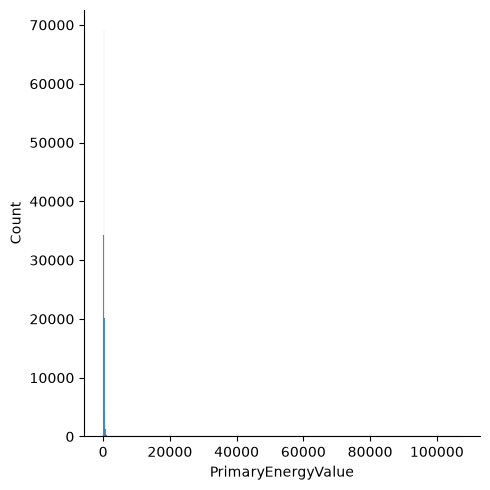

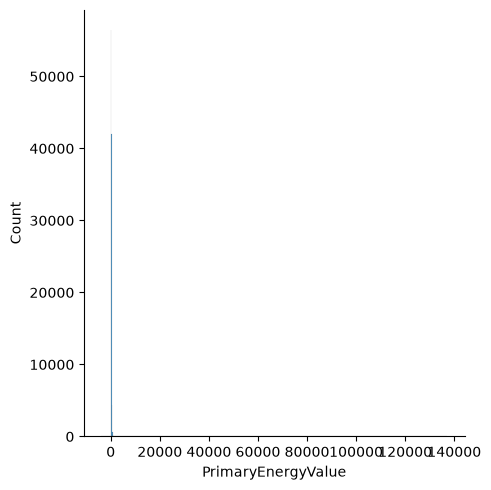

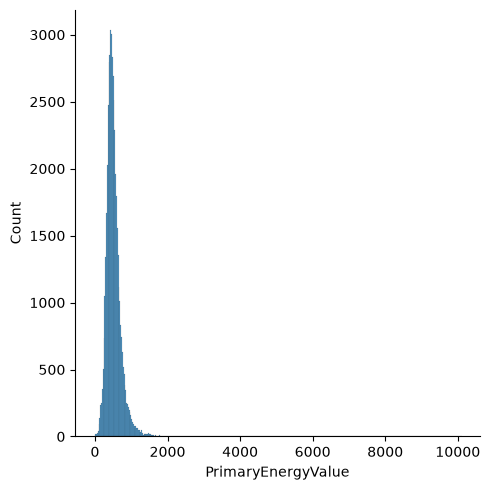

In [33]:
sns.displot(data=type_retail_financial["PrimaryEnergyValue"])
sns.displot(data=type_office["PrimaryEnergyValue"])
sns.displot(data=type_restaurant["PrimaryEnergyValue"])
plt.show()

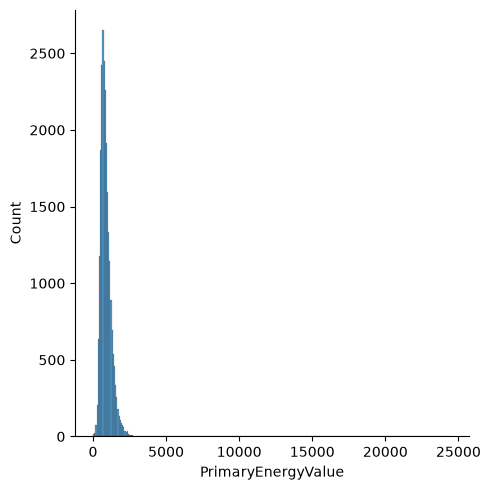

In [ ]:
sns.displot(data=df_plot["PrimaryEnergyValue"])

# Process EPC domestic

In [ ]:
sample_domestic = pd.read_csv("data/epc-domestic.csv", nrows=1000)
sample_domestic.head()

In [ ]:
sample_domestic.dtypes

In [ ]:
sample_domestic.describe()